## Import Libraries
The following libraries are used for data manipulation, visualization, and model training.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset
The dataset contains employee information related to retention, including satisfaction, salary, workload, and whether the employee left the company.

In [72]:
df = pd.read_csv("HR_comma_sep.csv")
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


## Perform EDA
Performed some EDA to understand what contributed more to a employee's retention rate

<Axes: xlabel='left', ylabel='count'>

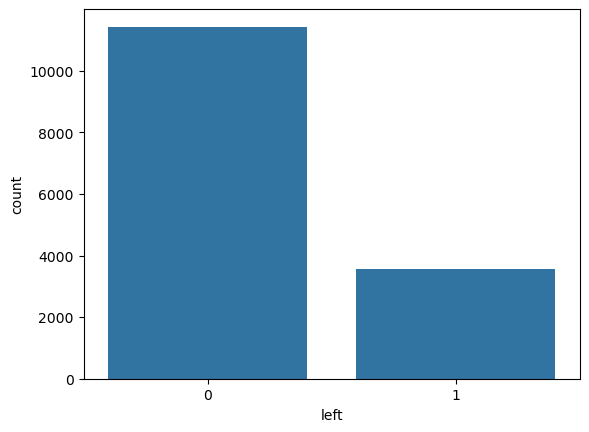

In [23]:
sns.countplot(x='left', data=df)

In [27]:
df.groupby('left').mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


<Axes: >

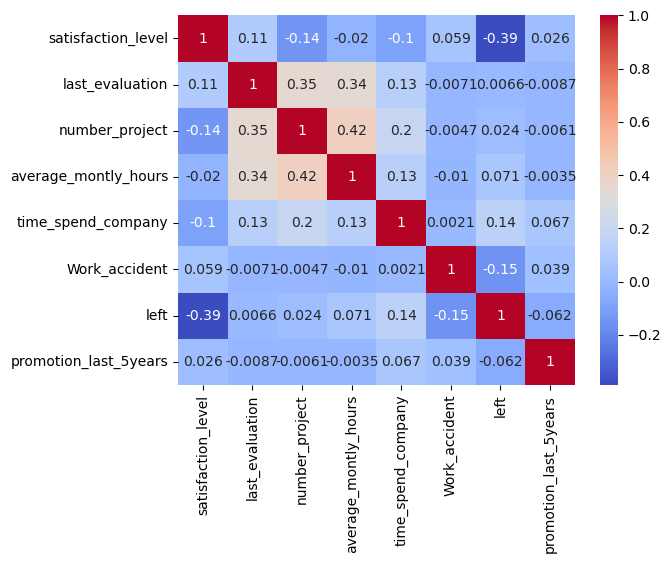

In [7]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

<Axes: xlabel='left', ylabel='satisfaction_level'>

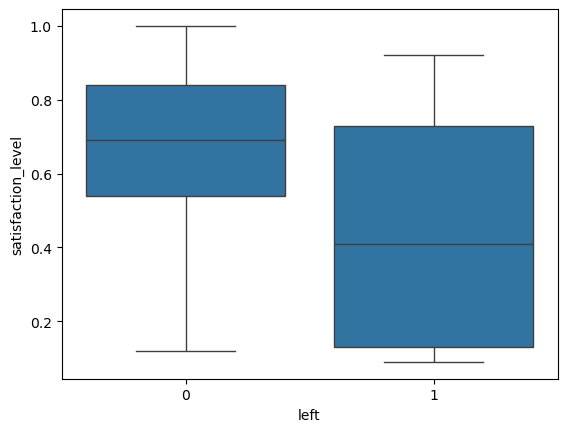

In [13]:
sns.boxplot(x='left', y='satisfaction_level', data=df)

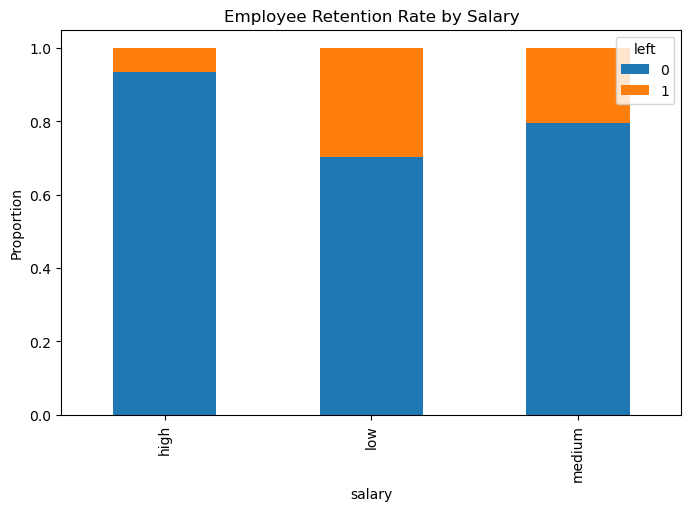

In [73]:
salary_pct = pd.crosstab(df.salary, df.left).div(pd.crosstab(df.salary, df.left).sum(1), axis=0)

salary_pct.plot(kind='bar', stacked=True, figsize=(8,5))
plt.ylabel("Proportion")
plt.title("Employee Retention Rate by Salary")
plt.show()

## Encode Salary Column
The categorical salary values are converted into numerical form so they can be used in the machine learning model.

In [74]:
df['salary'] = df['salary'].map({'low':0,'medium':1,'high':2})
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,0
1,0.80,0.86,5,262,6,0,1,0,sales,1
2,0.11,0.88,7,272,4,0,1,0,sales,1
3,0.72,0.87,5,223,5,0,1,0,sales,0
4,0.37,0.52,2,159,3,0,1,0,sales,0
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,0
14995,0.37,0.48,2,160,3,0,1,0,support,0
14996,0.37,0.53,2,143,3,0,1,0,support,0
14997,0.11,0.96,6,280,4,0,1,0,support,0


## Import Model and Train-Test Split
Logistic Regression is imported for classification, and train-test split is used to divide the data into training and testing sets.

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

model = LogisticRegression(class_weight='balanced',max_iter=1000)

## Define Features and Target
The feature set `X` contains the input variables used for prediction, while `y` represents whether an employee left the company.

In [76]:
X = df.drop(['last_evaluation','number_project','left','Department'],axis=1)
y= df.left

## Split the Dataset
The dataset is split into training and testing sets so the model can be trained on one portion and evaluated on unseen data.

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y, test_size=0.2)

## Train the Logistic Regression Model
The model is trained using the training data to learn patterns related to employee retention.

In [78]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Make Predictions and Evaluate Accuracy
The trained model is used to predict employee retention on the test set, and the accuracy score is calculated.

In [67]:
y_pred = model.predict(X_test)

In [79]:
model.score(X_test,y_test)

0.7566666666666667

## Classification Report and Confusion Matrix
The classification report provides precision, recall, and F1-score, while the confusion matrix shows the counts of correct and incorrect predictions.

In [69]:
from sklearn.metrics import classification_report, confusion_matrix
print ('Classification Report:', classification_report(y_test,y_pred))
print ('Confusion Matrix:', confusion_matrix(y_test,y_pred))

Classification Report:               precision    recall  f1-score   support

           0       0.92      0.74      0.82      2286
           1       0.49      0.79      0.60       714

    accuracy                           0.75      3000
   macro avg       0.70      0.77      0.71      3000
weighted avg       0.82      0.75      0.77      3000

Confusion Matrix: [[1698  588]
 [ 150  564]]


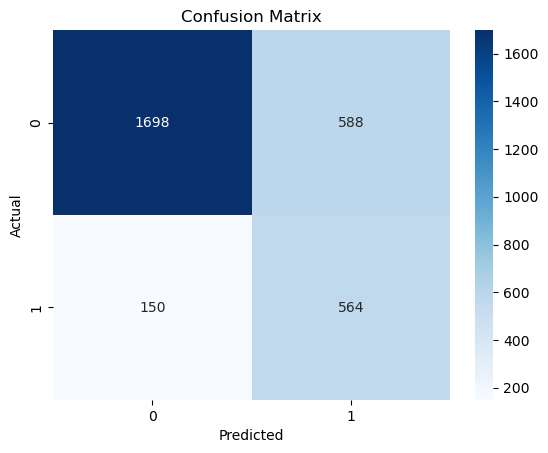

In [70]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()